In [ ]:
!wget https://files.grouplens.org/datasets/movielens/ml-100k.zip

--2026-07-01 14:23:19--  https://files.grouplens.org/datasets/movielens/ml-100k.zip
Resolving files.grouplens.org (files.grouplens.org)... 128.101.96.204
Connecting to files.grouplens.org (files.grouplens.org)|128.101.96.204|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4924029 (4.7M) [application/zip]
Saving to: ‘ml-100k.zip.1’

ml-100k.zip.1       100%[===================>]   4.70M  9.09MB/s    in 0.5s    

2026-07-01 14:23:20 (9.09 MB/s) - ‘ml-100k.zip.1’ saved [4924029/4924029]



In [ ]:
!unzip ml-100k.zip

Archive:  ml-100k.zip
replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace ml-100k/allbut.pl? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: ml-100k/allbut.pl       
  inflating: ml-100k/mku.sh          
  inflating: ml-100k/README          
  inflating: ml-100k/u.data          
  inflating: ml-100k/u.genre         
  inflating: ml-100k/u.info          
  inflating: ml-100k/u.item          
  inflating: ml-100k/u.occupation    
  inflating: ml-100k/u.user          
  inflating: ml-100k/u1.base         
  inflating: ml-100k/u1.test         
  inflating: ml-100k/u2.base         
  inflating: ml-100k/u2.test         
  inflating: ml-100k/u3.base         
  inflating: ml-100k/u3.test         
  inflating: ml-100k/u4.base         
  inflating: ml-100k/u4.test         
  inflating: ml-100k/u5.base         
  inflating: ml-100k/u5.test         
  inflating: ml-100k/ua.base         
  inflating: ml-100k/ua.test         
  inflating: ml-1

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
ratings = pd.read_csv(
    "ml-100k/u.data",
    sep = "\t",
    names = ["user_id","movie_id","rating", "timestamp"]
)
ratings.head()

,user_id,movie_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [ ]:
ratings.shape

(100000, 4)

In [ ]:
ratings.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype
---  ------     --------------   -----
 0   user_id    100000 non-null  int64
 1   movie_id   100000 non-null  int64
 2   rating     100000 non-null  int64
 3   timestamp  100000 non-null  int64
dtypes: int64(4)
memory usage: 3.1 MB


In [ ]:
ratings['user_id'].nunique()


943

In [ ]:
ratings['movie_id'].nunique()

1682

In [ ]:
ratings["rating"].value_counts().sort_index()

,count
rating,
1,6110
2,11370
3,27145
4,34174
5,21201


In [ ]:
from sklearn.preprocessing import LabelEncoder

user_encoder = LabelEncoder()
movie_encoder = LabelEncoder()

ratings["user"] = user_encoder.fit_transform(ratings["user_id"])
ratings["movie"] = movie_encoder.fit_transform(ratings["movie_id"])

ratings.head()

,user_id,movie_id,rating,timestamp,user,movie
0,196,242,3,881250949,195,241
1,186,302,3,891717742,185,301
2,22,377,1,878887116,21,376
3,244,51,2,880606923,243,50
4,166,346,1,886397596,165,345


In [ ]:
ratings[ratings['user'] == 242]['rating']

,rating
71,3
613,4
1486,4
3791,4
3912,3
...,...
78012,3
91104,3
93652,5
95524,4


In [ ]:
X_user = ratings["user"].values
X_movie = ratings["movie"].values
y = ratings["rating"].values

In [ ]:
print(X_user[:5])
print(X_movie[:5])
print(y[:5])

[195 185  21 243 165]
[241 301 376  50 345]
[3 3 1 2 1]


In [ ]:
from sklearn.model_selection import train_test_split

X_user_train, X_user_test, X_movie_train, X_movie_test, y_train, y_test = train_test_split(
    X_user,
    X_movie,
    y,
    test_size=0.2,
    random_state=42
)

print(len(X_user_train))
print(len(X_user_test))

80000
20000


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding
from tensorflow.keras.layers import Flatten, Concatenate
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Model

In [ ]:
user_input = Input(shape=(1,))
movie_input = Input(shape=(1,))

In [ ]:
user_embedding = Embedding(
    input_dim=943,
    output_dim=32
)(user_input)

movie_embedding = Embedding(
    input_dim=1682,
    output_dim=32
)(movie_input)

In [ ]:
user_vec = Flatten()(user_embedding)
movie_vec = Flatten()(movie_embedding)

In [ ]:
x = Concatenate()([user_vec, movie_vec])

In [ ]:
x = Dense(128, activation="relu")(x)

x = Dense(64, activation="relu")(x)

In [ ]:
output = Dense(1)(x)

In [ ]:
model = Model(
    inputs=[user_input, movie_input],
    outputs=output
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │     30,176 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 32)     │     53,824 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      8,320 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 100,641 (393.13 KB)

 Trainable params: 100,641 (393.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history = model.fit(
    [X_user_train, X_movie_train],
    y_train,
    validation_split=0.1,
    epochs=10,
    batch_size=256
)

Epoch 1/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 2.1637 - mae: 1.0725 - val_loss: 0.9248 - val_mae: 0.7631
Epoch 2/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8898 - mae: 0.7472 - val_loss: 0.9148 - val_mae: 0.7648
Epoch 3/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8720 - mae: 0.7395 - val_loss: 0.9029 - val_mae: 0.7539
Epoch 4/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8571 - mae: 0.7318 - val_loss: 0.8921 - val_mae: 0.7524
Epoch 5/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8360 - mae: 0.7206 - val_loss: 0.8888 - val_mae: 0.7540
Epoch 6/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.8152 - mae: 0.7114 - val_loss: 0.8900 - val_mae: 0.7362
Epoch 7/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7905 - mae: 0.6992 - val_loss: 0.8775 - val_mae: 0.7377
Epoch 8/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.7606 - mae: 0.6856 - val_loss: 0.8862 - val_mae: 0.7375
Epoch 9/10
282/282 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │     30,176 │ input_layer_4[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 32)     │     53,824 │ input_layer_5[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_4 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_5 (Flatten) │ (None, 32)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 64)        │          0 │ flatten_4[0][0],  │
│ (Concatenate)       │                   │            │ flatten_5[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_6 (Dense)     │ (None, 128)       │      8,320 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_7 (Dense)     │ (None, 64)        │      8,256 │ dense_6[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 1)         │         65 │ dense_7[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 301,925 (1.15 MB)

 Trainable params: 100,641 (393.13 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 201,284 (786.27 KB)

In [ ]:
movies = pd.read_csv(
    "ml-100k/u.item",
    sep = "|",
    encoding = "latin-1",
    header = None,
    usecols = [0,1],
    names = ["movie_id","title"]
)
movies.head()

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)


In [ ]:
movies.shape

(1682, 2)

In [ ]:
movies.head(10)

,movie_id,title
0,1,Toy Story (1995)
1,2,GoldenEye (1995)
2,3,Four Rooms (1995)
3,4,Get Shorty (1995)
4,5,Copycat (1995)
5,6,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
6,7,Twelve Monkeys (1995)
7,8,Babe (1995)
8,9,Dead Man Walking (1995)
9,10,Richard III (1995)


In [ ]:
user_id = 0
all_movies = np.arange(1682)
user_array = np.full(
    shape=len(all_movies),
    fill_value=user_id
)

predictions = model.predict(
    [user_array, all_movies],
    verbose=0
)




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
predictions.shape

(1682, 1)

In [ ]:
top_indices = np.argsort(
    predictions.flatten()
)[::-1][:10]

In [ ]:
recommended_movie_ids = movie_encoder.inverse_transform(
    top_indices
)

In [ ]:
recommended_movies = movies[
    movies["movie_id"].isin(recommended_movie_ids)
]

In [ ]:
recommended_movies

,movie_id,title
11,12,"Usual Suspects, The (1995)"
113,114,Wallace & Gromit: The Best of Aardman Animatio...
133,134,Citizen Kane (1941)
301,302,L.A. Confidential (1997)
407,408,"Close Shave, A (1995)"
426,427,To Kill a Mockingbird (1962)
1200,1201,Marlene Dietrich: Shadow and Light (1996)
1448,1449,Pather Panchali (1955)
1499,1500,Santa with Muscles (1996)
1628,1629,Nico Icon (1995)


In [ ]:
movie_counts = ratings.groupby(
    "movie_id"
)["rating"].count()

movie_counts.head()

,rating
movie_id,
1,452
2,131
3,90
4,209
5,86


In [ ]:
popular_movies = movie_counts[
    movie_counts >= 50
].index

In [ ]:
all_movies = np.arange(1682)

In [ ]:
all_movie_ids = movie_encoder.transform(
    popular_movies
)

In [ ]:
rated_movies = ratings[
    ratings["user"] == user_id
]["movie"]

In [ ]:
candidate_movies = np.setdiff1d(
    all_movie_ids,
    rated_movies
)

In [ ]:
candidate_movies

array([ 272,  273,  274,  275,  276,  277,  279,  280,  281,  282,  283,
        284,  285,  286,  287,  288,  289,  290,  291,  292,  293,  294,
        296,  297,  298,  299,  300,  301,  302,  303,  304,  305,  306,
        309,  310,  311,  312,  314,  315,  316,  317,  318,  320,  321,
        322,  323,  324,  325,  326,  327,  330,  331,  332,  333,  337,
        339,  341,  342,  343,  344,  345,  346,  353,  355,  356,  357,
        366,  368,  370,  377,  379,  380,  381,  383,  384,  385,  386,
        390,  391,  392,  394,  395,  398,  400,  401,  402,  403,  404,
        407,  408,  409,  410,  411,  412,  413,  415,  416,  417,  418,
        419,  420,  422,  424,  426,  427,  428,  429,  430,  431,  432,
        433,  434,  435,  440,  442,  446,  447,  448,  449,  450,  451,
        454,  457,  460,  461,  462,  464,  465,  467,  468,  469,  470,
        471,  472,  473,  474,  475,  476,  477,  478,  479,  480,  481,
        482,  483,  484,  485,  486,  487,  488,  4

In [ ]:
def recommend_movies(user_id, top_n=10):

    movie_counts = ratings.groupby("movie_id")["rating"].count()

    popular_movies = movie_counts[
        movie_counts >= 50
    ].index

    candidate_movies = movie_encoder.transform(popular_movies)

    watched_movies = ratings[
        ratings["user"] == user_id
    ]["movie"].values

    candidate_movies = np.setdiff1d(
        candidate_movies,
        watched_movies
    )

    user_array = np.full(
        len(candidate_movies),
        user_id
    )

    predictions = model.predict(
        [user_array, candidate_movies],
        verbose=0
    ).flatten()

    top_indices = np.argsort(
        predictions
    )[::-1][:top_n]

    recommended_movies = candidate_movies[top_indices]

    movie_ids = movie_encoder.inverse_transform(
        recommended_movies
    )

    return movies[
        movies["movie_id"].isin(movie_ids)
    ][["movie_id", "title"]]

In [ ]:
recommend_movies(0)

,movie_id,title
301,302,L.A. Confidential (1997)
312,313,Titanic (1997)
314,315,Apt Pupil (1998)
407,408,"Close Shave, A (1995)"
426,427,To Kill a Mockingbird (1962)
482,483,Casablanca (1942)
510,511,Lawrence of Arabia (1962)
518,519,"Treasure of the Sierra Madre, The (1948)"
602,603,Rear Window (1954)
656,657,"Manchurian Candidate, The (1962)"


In [ ]:
model.save("movie_recommender.keras")

In [ ]:
movies.to_csv("movies.csv", index=False)

In [ ]:
import pickle

with open("user_encoder.pkl", "wb") as f:
    pickle.dump(user_encoder, f)

with open("movie_encoder.pkl", "wb") as f:
    pickle.dump(movie_encoder, f)

In [ ]:
from google.colab import files
files.download("user_encoder.pkl")
files.download("movie_encoder.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
ratings.to_csv("ratings.csv", index=False)

In [ ]:
files.download("ratings.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model.save("movie_recommender.keras")

movies.to_csv("movies.csv", index=False)
ratings.to_csv("ratings.csv", index=False)

In [ ]:
user_id = 0

recommendations = recommend_movies(user_id)

print("Top Recommendations:\n")

for movie in recommendations["title"]:
    print(movie)

Top Recommendations:

L.A. Confidential (1997)
Titanic (1997)
Apt Pupil (1998)
Close Shave, A (1995)
To Kill a Mockingbird (1962)
Casablanca (1942)
Lawrence of Arabia (1962)
Treasure of the Sierra Madre, The (1948)
Rear Window (1954)
Manchurian Candidate, The (1962)


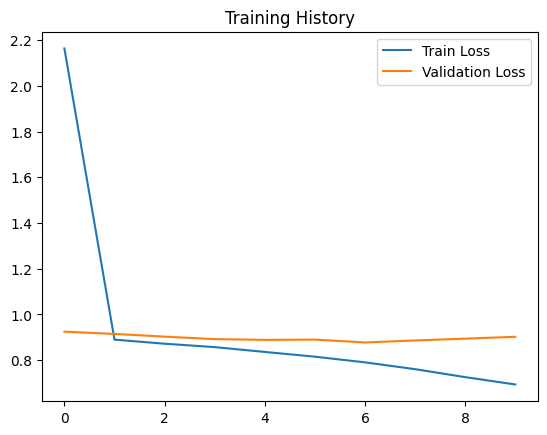

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Training History")
plt.show()